# 10. Modelos explicativos y prediccion de precio

Este notebook explora relaciones estructurales del mercado inmobiliario mediante dos modelos:

- **Ridge Regression** como modelo baseline lineal, regularizado e interpretable.
- **Random Forest Regressor** como modelo no lineal mas potente, capaz de capturar interacciones.

El objetivo es estimar el precio publicado de una propiedad y entender que atributos aportan mayor informacion. Los modelos sirven como apoyo para tasacion preliminar y deteccion de avisos que merecen revision; no representan precios de cierre ni rentabilidad real.

## Estrategia metodologica

Para evitar fuga de informacion, el modelo parte de `../data/interim/Argenprop_Enriched.tsv`, es decir, del dataset anterior a la limpieza e imputacion general.

1. Se conservan solamente avisos cuyo precio fue observado en USD. El target no se imputa.
2. Se convierten precios, expensas, piso y superficies a formato numerico, manteniendo sus faltantes como `NaN`.
3. Se excluyen identificadores, textos libres, campos duplicados y cualquier variable derivada del precio.
4. Train y test se separan por ubicacion. Propiedades de un mismo edificio o coordenada quedan en un solo conjunto.
5. La imputacion de variables explicativas, el escalado y el One-Hot Encoding se ajustan exclusivamente con train mediante `Pipeline`.
6. La misma regla se respeta dentro de cada repeticion de validacion agrupada.

Ambos modelos usan exactamente el mismo train y test. Como el precio es asimetrico, se aprende sobre `log1p(Precio)` y las metricas se calculan nuevamente en dolares.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import RidgeCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42
DATA_PATH = "../data/interim/Argenprop_Enriched.tsv"

df = pd.read_csv(
    DATA_PATH,
    sep="\t",
    encoding="utf-8-sig",
    low_memory=False,
)

print(f"Dataset sin imputar: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")
df.head()

Dataset sin imputar: 7,991 filas x 67 columnas


,Precio,Expensas,Calle,Altura,Piso,Detalles,Descripción,Link,Ambientes,Dormitorios,Baños,Toilettes,Estado,Antiguedad,Disposicion,Tipo_Balcon,Tipo_Unidad,Sup_Cubierta_m2,Sup_Total_m2,Precio_Ficha,Expensas_Ficha,Cant_Pisos_Edificio,Deptos_Por_Piso,Estado_Edificio,Aire_acondicionado_individual,Losa_radiante,Gas_natural,Agua_corriente,Balcón,Terraza,Jardín,Patio,Baulera,Cochera,Muebles_de_cocina,Lavarropas,Lavavajillas,Permite_Mascotas,Ascensor,Pileta,Piscina,Parrilla,SUM,Gimnasio,Sauna,Laundry,Seguridad_24hs,Vigilancia,Latitud,Longitud,Procesada,Barrio,Comuna,Dist_Subte_m,Subte_cercano,Linea_subte,Dist_Hospital_m,Hospital_cercano,Dist_Colegio_m,Colegios_500m,Dist_Comisaria_m,Dist_Gimnasio_m,Dist_Supermercado_m,Supermercados_500m,Dist_Avenida_m,Avenida_cercana,Paradas_colectivo_300m
0,USD 2.500.000,+ $2.400.000,Jerónimo Salguero,"2,700.00",NaN,280 m² cubie. 3 dorm. 17 años,“TORRE BELLINI” DE REVISTA! IMPECABLE PISO MUY...,https://www.argenprop.com/departamento-en-vent...,5.00,3.00,4.00,1.00,Excelente,17.00,Frente,Corrido,Departamento,280,280,USD 2.500.000,$ 2.400.000,37.00,NaN,Excelente,0,0,0,1,1,0,0,0,1,1,1,0,0,0,1,1,0,1,0,1,1,1,0,1,-34.59,-58.42,True,Palermo,14.00,910.50,BULNES,D,569.60,R. Gutierrez,263.23,6,741.61,215.13,151.48,16,4.02,Avenida Honduras,5
1,USD 150.000,+ $260.000,Bulnes,"1,600.00",NaN,60 m² cubie. 2 dorm. 30 años,IMPECABLE! BALCÓN CORRIDO AL FRENTE CON VISTA ...,https://www.argenprop.com/departamento-en-vent...,3.00,2.00,1.00,NaN,Excelente,30.00,Frente,Corrido,Departamento,60,60,USD 150.000,$ 260.000,8.00,NaN,Excelente,1,0,1,1,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,-34.59,-58.41,True,Palermo,14.00,167.78,BULNES,D,719.19,Dr. J. A. Fernandez,180.35,10,493.13,51.73,20.28,10,156.79,Avenida Santa Fe,19
2,USD 330.000,+ $203.300,ARAOZ,"1,200.00",Piso 8,90 m² cubie. 3 dorm. A Estrenar,Venta 4 AMBIENTES con balcón Palermo + Cochera...,https://www.argenprop.com/departamento-en-vent...,4.00,3.00,2.00,NaN,Bueno,NaN,Contrafrente,NaN,NaN,90,96,USD 330.000,$ 203.300,9.00,4.00,NaN,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,-34.59,-58.42,True,Palermo,14.00,563.73,R.SCALABRINI ORTIZ,D,948.62,R. Gutierrez,188.54,11,403.11,429.58,249.25,4,96.51,Avenida Raúl Scalabrini Ortiz,10
3,USD 270.000,+ $300.000,Honduras,"3,900.00",Piso 2,87 m² cubie. 2 dorm. 20 años,"Venta Semipiso 4 Ambientes, Dos Baños completo...",https://www.argenprop.com/departamento-en-vent...,4.00,2.00,2.00,NaN,Excelente,20.00,Frente,Terraza,Semipiso,87,87,USD 270.000,$ 300.000,4.00,2.00,Excelente,1,0,1,1,1,1,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,-34.58,-58.44,True,Palermo,14.00,815.47,MINISTRO CARRANZA - MIGUEL ABUELO,D,"2,930.40",Hospital Municipal de Oncologia M. Curie,240.87,7,891.15,383.02,75.24,7,425.50,Avenida Coronel Niceto Vega,5
4,USD 570.000,+ $1.000.000,Castex,"3,300.00",NaN,140 m² cubie. 3 dorm. 40 años,PALERMO CHICO espectacular piso alto con vista...,https://www.argenprop.com/departamento-en-vent...,4.00,3.00,3.00,NaN,NaN,40.00,NaN,NaN,Piso,140,160,USD 570.000,$ 1.000.000,NaN,NaN,NaN,0,1,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,-34.58,-58.41,True,Palermo,14.00,"1,262.25",R.SCALABRINI ORTIZ,D,559.87,Dr. J. A. Fernandez,256.80,4,804.14,286.70,217.08,3,108.44,Avenida Casares,7


## Seleccion del target observado

El target se obtiene directamente de `Precio`. Solo se conservan publicaciones cuyo valor original comienza con `USD`.

Los avisos con precio `"Consultar"` se excluyen, porque no existe un valor observado contra el cual entrenar o evaluar. El precio se convierte a numero, pero nunca se completa mediante imputacion.

Tambien se aplica un rango de plausibilidad de USD 25.000 a USD 1.500.000 para evitar que errores de publicacion o propiedades excepcionalmente atipicas dominen las metricas. Este filtro elimina observaciones, no reemplaza ni imputa el target.

In [2]:
target = "Precio_USD"

mask_precio_observado = (
    df["Precio"]
    .astype("string")
    .str.startswith("USD ", na=False)
)

df_modelo = df.loc[mask_precio_observado].copy()
df_modelo[target] = pd.to_numeric(
    df_modelo["Precio"]
    .astype("string")
    .str.replace("USD ", "", regex=False)
    .str.replace(".", "", regex=False),
    errors="coerce",
)

df_modelo = (
    df_modelo
    .dropna(subset=[target])
    .loc[lambda data: data[target].between(25_000, 1_500_000)]
    .reset_index(drop=True)
)

print(f"Precios observados utilizados: {len(df_modelo):,}")
print(
    "Avisos sin precio USD o fuera del rango de plausibilidad excluidos:",
    f"{len(df) - len(df_modelo):,}",
)
df_modelo[target].describe(percentiles=[0.50, 0.90, 0.95, 0.99])

Precios observados utilizados: 7,901
Avisos sin precio USD o fuera del rango de plausibilidad excluidos: 90


count       7,901.00
mean      175,542.58
std       161,386.09
min        25,000.00
50%       128,000.00
90%       330,000.00
95%       472,242.00
99%       890,000.00
max     1,500,000.00
Name: Precio_USD, dtype: Float64

## Preparacion de variables sin imputar

Las conversiones de formato no completan valores faltantes:

- expensas y superficies se convierten a numero;
- `Piso PB` se representa como 0 y los demas pisos se extraen del texto;
- valores imposibles o faltantes permanecen como `NaN`.

Se seleccionan variables disponibles antes de conocer el precio: caracteristicas estructurales, estado, amenities y contexto territorial. Calle, altura, link, descripcion, detalles y campos duplicados se excluyen.

In [3]:
def extraer_numero(series):
    return pd.to_numeric(
        series.astype("string").str.extract(r"(\d+(?:[.,]\d+)?)", expand=False)
        .str.replace(",", ".", regex=False),
        errors="coerce",
    )


df_modelo["Expensas_num"] = pd.to_numeric(
    df_modelo["Expensas"]
    .astype("string")
    .str.replace(r"[^0-9]", "", regex=True),
    errors="coerce",
)

piso_texto = df_modelo["Piso"].astype("string").str.upper()
df_modelo["Piso_num"] = extraer_numero(piso_texto)
df_modelo.loc[piso_texto.str.contains(r"\bPB\b", na=False), "Piso_num"] = 0

for origen, destino in {
    "Sup_Cubierta_m2": "Sup_Cubierta_m2_num",
    "Sup_Total_m2": "Sup_Total_m2_num",
}.items():
    df_modelo[destino] = extraer_numero(df_modelo[origen])

amenities = [
    "Aire_acondicionado_individual", "Losa_radiante", "Gas_natural",
    "Agua_corriente", "Balcón", "Terraza", "Jardín", "Patio",
    "Baulera", "Cochera", "Muebles_de_cocina", "Lavarropas",
    "Lavavajillas", "Permite_Mascotas", "Ascensor", "Pileta",
    "Piscina", "Parrilla", "SUM", "Gimnasio", "Sauna", "Laundry",
    "Seguridad_24hs", "Vigilancia",
]

numeric_features = [
    "Expensas_num", "Piso_num", "Ambientes", "Dormitorios", "Baños",
    "Antiguedad", "Sup_Cubierta_m2_num", "Sup_Total_m2_num",
    *amenities,
    "Latitud", "Longitud", "Comuna", "Dist_Subte_m",
    "Dist_Hospital_m", "Dist_Colegio_m", "Colegios_500m",
    "Dist_Comisaria_m", "Dist_Gimnasio_m", "Dist_Supermercado_m",
    "Supermercados_500m", "Dist_Avenida_m", "Paradas_colectivo_300m",
]

categorical_features = [
    "Estado", "Disposicion", "Tipo_Unidad", "Barrio",
    "Subte_cercano", "Linea_subte", "Hospital_cercano",
    "Avenida_cercana",
]

features = numeric_features + categorical_features
X = df_modelo[features].copy()
y = df_modelo[target].astype(float).copy()

print("Variables numericas:", len(numeric_features))
print("Variables categoricas:", len(categorical_features))
print("Valores faltantes en features:", int(X.isna().sum().sum()))
print("Valores faltantes en target:", int(y.isna().sum()))

Variables numericas: 45
Variables categoricas: 8
Valores faltantes en features: 18188
Valores faltantes en target: 0


## Separacion train/test por ubicacion

Una division aleatoria puede colocar departamentos del mismo edificio en train y test. Eso facilita artificialmente la prediccion, porque ambos conjuntos contienen propiedades casi identicas y con el mismo entorno.

Se usa `GroupShuffleSplit`:

- si hay coordenadas, se agrupan redondeadas a 5 decimales;
- si faltan, se usa la combinacion calle-altura;
- un grupo completo queda exclusivamente en train o en test.

El test contiene aproximadamente 20% de los avisos y simula mejor la prediccion sobre ubicaciones no vistas.

In [4]:
grupo_coordenadas = (
    df_modelo["Latitud"].round(5).astype("string")
    + "|"
    + df_modelo["Longitud"].round(5).astype("string")
)

grupo_direccion = (
    df_modelo["Calle"].fillna("").astype("string").str.lower().str.strip()
    + "|"
    + df_modelo["Altura"].fillna("").astype("string")
)

tiene_coordenadas = (
    df_modelo["Latitud"].notna()
    & df_modelo["Longitud"].notna()
)

grupos = grupo_coordenadas.where(tiene_coordenadas, grupo_direccion)

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)
train_idx, test_idx = next(splitter.split(X, y, groups=grupos))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
grupos_train, grupos_test = grupos.iloc[train_idx], grupos.iloc[test_idx]

solapamiento = set(grupos_train).intersection(set(grupos_test))

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Ubicaciones en train:", grupos_train.nunique())
print("Ubicaciones en test:", grupos_test.nunique())
print("Ubicaciones compartidas:", len(solapamiento))

Train: (6470, 53) Test: (1431, 53)
Ubicaciones en train: 1362
Ubicaciones en test: 341
Ubicaciones compartidas: 0


## Metricas de evaluacion

Se reportan:

- **MAE:** error absoluto promedio en USD.
- **RMSE:** penaliza especialmente los errores grandes.
- **MedAE:** error absoluto mediano, menos sensible a propiedades extremas.
- **MAPE:** error porcentual promedio.
- **R2:** proporcion de variabilidad explicada en test.

MAE y MAPE son las metricas principales para la lectura comercial. R2 se usa como complemento.

In [5]:
def evaluar_modelo(nombre, modelo, X_eval, y_eval):
    pred = modelo.predict(X_eval)
    errores_abs = np.abs(y_eval.to_numpy() - pred)

    metricas = {
        "modelo": nombre,
        "MAE_USD": mean_absolute_error(y_eval, pred),
        "RMSE_USD": mean_squared_error(y_eval, pred) ** 0.5,
        "MedAE_USD": median_absolute_error(y_eval, pred),
        "MAPE_%": np.mean(errores_abs / y_eval.to_numpy()) * 100,
        "R2": r2_score(y_eval, pred),
    }
    return metricas, pred


def plot_predicho_vs_real(y_real, pred, titulo):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_real, pred, alpha=0.35, s=18)
    limite = max(y_real.max(), pred.max())
    ax.plot([0, limite], [0, limite], color="red", linestyle="--")
    ax.set_xlabel("Precio real (USD)")
    ax.set_ylabel("Precio predicho (USD)")
    ax.set_title(titulo)
    ax.grid(alpha=0.15)
    plt.tight_layout()
    plt.show()

## Modelo baseline: Ridge Regression

Ridge es una regresion lineal con regularizacion L2. Funciona como baseline porque ofrece una referencia sencilla e interpretable:

- modela relaciones lineales;
- controla parcialmente la multicolinealidad;
- permite estudiar signos y magnitudes de coeficientes;
- muestra cuanto puede explicarse sin recurrir a interacciones complejas.

Las variables numericas se imputan y estandarizan. Las categoricas se imputan y codifican mediante One-Hot Encoding. Todo el preprocesamiento se ajusta solamente con train.

In [6]:
numeric_pipeline_ridge = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=20,
            sparse_output=False,
        ),
    ),
])

preprocess_ridge = ColumnTransformer([
    ("num", numeric_pipeline_ridge, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
], verbose_feature_names_out=False)

ridge_pipeline = Pipeline([
    ("preprocess", preprocess_ridge),
    ("model", RidgeCV(alphas=np.logspace(-2, 4, 25))),
])

ridge_model = TransformedTargetRegressor(
    regressor=ridge_pipeline,
    func=np.log1p,
    inverse_func=np.expm1,
)

ridge_model.fit(X_train, y_train)
evaluacion_ridge, ridge_pred = evaluar_modelo(
    "Ridge baseline",
    ridge_model,
    X_test,
    y_test,
)

print(
    "Alpha seleccionado:",
    ridge_model.regressor_.named_steps["model"].alpha_,
)
pd.DataFrame([evaluacion_ridge]).round(3)

Alpha seleccionado: 5.623413251903491


,modelo,MAE_USD,RMSE_USD,MedAE_USD,MAPE_%,R2
0,Ridge baseline,"49,137.64","104,603.99","23,550.79",25.04,0.59


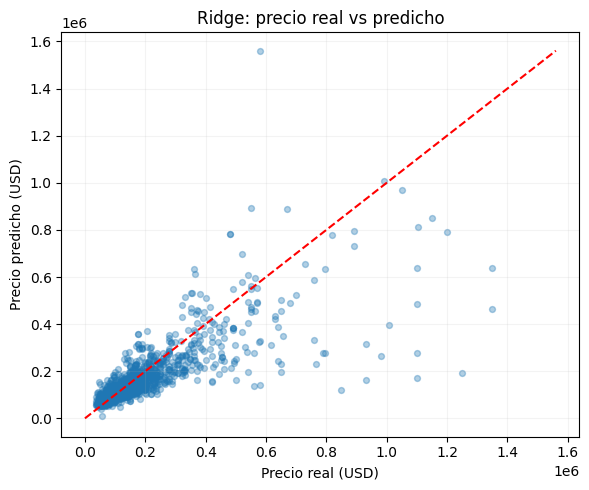

In [7]:
plot_predicho_vs_real(
    y_test,
    ridge_pred,
    "Ridge: precio real vs predicho",
)

### Interpretacion de Ridge

El modelo aprende sobre `log(Precio)`:

- para una variable numerica, el coeficiente representa el cambio aproximado ante un aumento de un desvio estandar;
- para una categoria, representa la diferencia respecto de la categoria de referencia;
- coeficientes positivos se asocian con mayor precio y negativos con menor precio.

Los coeficientes describen asociaciones dentro del modelo, no efectos causales.

In [8]:
ridge_inner = ridge_model.regressor_
feature_names_ridge = (
    ridge_inner.named_steps["preprocess"].get_feature_names_out()
)
coeficientes = ridge_inner.named_steps["model"].coef_

ridge_coef = (
    pd.DataFrame({
        "feature": feature_names_ridge,
        "coef_log_precio": coeficientes,
        "impacto_aprox_%": (np.exp(coeficientes) - 1) * 100,
    })
    .sort_values("coef_log_precio", ascending=False)
)

top_ridge = pd.concat([
    ridge_coef.head(12),
    ridge_coef.tail(12),
])

top_ridge

,feature,coef_log_precio,impacto_aprox_%
84,Barrio_Puerto Madero,0.33,39.67
266,Avenida_cercana_Avenida Pedro Goyena,0.30,35.23
285,Avenida_cercana_Azucena Villaflor,0.22,25.14
7,Sup_Total_m2_num,0.22,24.26
156,Subte_cercano_PLAZA DE MAYO,0.21,23.19
2,Ambientes,0.18,20.18
47,Estado_Excelente,0.17,17.97
86,Barrio_Retiro,0.16,17.49
247,Avenida_cercana_Avenida General Las Heras,0.16,17.26
225,Avenida_cercana_Avenida Cerviño,0.15,16.45


## Modelo no lineal: Random Forest

Random Forest es el modelo mas potente de la comparacion. Puede capturar:

- relaciones no lineales entre superficie y precio;
- interacciones entre ubicacion, estado y atributos;
- distintos efectos de amenities segun el tipo de propiedad;
- umbrales que una regresion lineal no representa bien.

Para controlar el sobreajuste se limita la profundidad maxima del arbol y se exige una cantidad minima de observaciones por hoja. Ademas, cada division puede evaluar el 50% de las variables disponibles. Esta configuracion fue elegida comparando alternativas mediante las mismas divisiones agrupadas, priorizando menor MAE de validacion y estabilidad.

Luego del entrenamiento se comparan las metricas de train y test. Una ventaja excesiva en train indicaria sobreajuste; una brecha moderada es esperable en un modelo flexible y debe analizarse junto con la validacion agrupada.

In [9]:
numeric_pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

preprocess_rf = ColumnTransformer([
    ("num", numeric_pipeline_rf, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
], verbose_feature_names_out=False)

rf_pipeline = Pipeline([
    ("preprocess", preprocess_rf),
    (
        "model",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=18,
            min_samples_leaf=5,
            max_features=0.5,
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
    ),
])

rf_model = TransformedTargetRegressor(
    regressor=rf_pipeline,
    func=np.log1p,
    inverse_func=np.expm1,
)

rf_model.fit(X_train, y_train)
evaluacion_rf, rf_pred = evaluar_modelo(
    "Random Forest",
    rf_model,
    X_test,
    y_test,
)

evaluacion_rf_train, _ = evaluar_modelo(
    "Random Forest - train",
    rf_model,
    X_train,
    y_train,
)

comparacion_generalizacion_rf = pd.DataFrame([
    evaluacion_rf_train,
    evaluacion_rf,
]).round({
    "MAE_USD": 0,
    "RMSE_USD": 0,
    "MedAE_USD": 0,
    "MAPE_%": 2,
    "R2": 3,
})

comparacion_generalizacion_rf

,modelo,MAE_USD,RMSE_USD,MedAE_USD,MAPE_%,R2
0,Random Forest - train,"22,916.00","53,678.00","9,928.00",11.43,0.89
1,Random Forest,"41,337.00","90,446.00","19,477.00",21.13,0.69


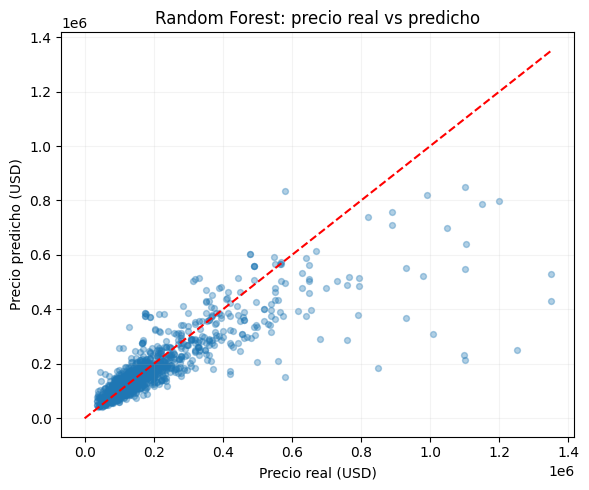

In [10]:
plot_predicho_vs_real(
    y_test,
    rf_pred,
    "Random Forest: precio real vs predicho",
)

## Comparacion de modelos

Los dos modelos se evaluan sobre las mismas ubicaciones no vistas del test final. Esta tabla representa una unica particion reservada y permite comparar ambos modelos bajo exactamente las mismas condiciones.

No se debe elegir el modelo observando solamente una metrica. Se priorizan MAE, MAPE y MedAE por su interpretacion comercial, mientras que R2 se usa como complemento para medir variabilidad explicada.

In [11]:
comparacion_modelos = pd.DataFrame([
    evaluacion_ridge,
    evaluacion_rf,
]).round({
    "MAE_USD": 0,
    "RMSE_USD": 0,
    "MedAE_USD": 0,
    "MAPE_%": 2,
    "R2": 3,
})

comparacion_modelos

,modelo,MAE_USD,RMSE_USD,MedAE_USD,MAPE_%,R2
0,Ridge baseline,"49,138.00","104,604.00","23,551.00",25.04,0.59
1,Random Forest,"41,337.00","90,446.00","19,477.00",21.13,0.69


In [12]:
mejora_mae = (
    comparacion_modelos.loc[0, "MAE_USD"]
    - comparacion_modelos.loc[1, "MAE_USD"]
) / comparacion_modelos.loc[0, "MAE_USD"] * 100

mejora_r2 = (
    comparacion_modelos.loc[1, "R2"]
    - comparacion_modelos.loc[0, "R2"]
)

print(
    "Reduccion de MAE de Random Forest respecto de Ridge: "
    f"{mejora_mae:.1f}%"
)
print(f"Mejora absoluta de R2: {mejora_r2:.3f}")

Reduccion de MAE de Random Forest respecto de Ridge: 15.9%
Mejora absoluta de R2: 0.104


## Validacion agrupada repetida sobre train

La comparacion anterior usa un unico test final. Para verificar que el resultado no dependa de una division especialmente favorable, se realizan cinco divisiones agrupadas adicionales dentro del conjunto de entrenamiento.

La validacion respeta las mismas reglas:

- las propiedades de una ubicacion permanecen juntas;
- en cada repeticion, una ubicacion aparece en entrenamiento o validacion, nunca en ambos;
- cada pipeline vuelve a ajustar imputacion, escalado, One-Hot Encoding y modelo usando solamente la particion de entrenamiento;
- el test final no participa y permanece reservado para la evaluacion principal.

Se reportan promedio y desvio estandar. Cada repeticion utiliza un conjunto distinto de ubicaciones para validacion:

- el resultado del **test final** corresponde a una sola particion reservada;
- el **promedio de validacion** combina cinco resultados distintos y aproxima el rendimiento habitual del modelo;
- el **desvio** muestra cuanto cambia el rendimiento segun las ubicaciones seleccionadas.

Por eso el R2 del test final puede ser diferente del R2 promedio. No son dos calculos sobre los mismos datos: uno describe una particion concreta y el otro resume cinco escenarios adicionales.

In [13]:
cv_agrupado = GroupShuffleSplit(
    n_splits=5,
    test_size=0.20,
    random_state=RANDOM_STATE,
)
resultados_cv = []

for repeticion, (cv_train_idx, cv_valid_idx) in enumerate(
    cv_agrupado.split(X_train, y_train, groups=grupos_train),
    start=1,
):
    X_cv_train = X_train.iloc[cv_train_idx]
    X_cv_valid = X_train.iloc[cv_valid_idx]
    y_cv_train = y_train.iloc[cv_train_idx]
    y_cv_valid = y_train.iloc[cv_valid_idx]

    modelos_cv = {
        "Ridge baseline": clone(ridge_model),
        "Random Forest": clone(rf_model),
    }

    for nombre, modelo in modelos_cv.items():
        modelo.fit(X_cv_train, y_cv_train)
        metricas, _ = evaluar_modelo(
            nombre,
            modelo,
            X_cv_valid,
            y_cv_valid,
        )
        metricas["repeticion"] = repeticion
        metricas["propiedades_validacion"] = len(cv_valid_idx)
        resultados_cv.append(metricas)

resultados_cv = pd.DataFrame(resultados_cv)

resultados_cv[[
    "repeticion",
    "modelo",
    "propiedades_validacion",
    "MAE_USD",
    "MAPE_%",
    "R2",
]].round({
    "MAE_USD": 0,
    "MAPE_%": 2,
    "R2": 3,
})

,repeticion,modelo,propiedades_validacion,MAE_USD,MAPE_%,R2
0,1,Ridge baseline,1297,"53,121.00",26.52,0.46
1,1,Random Forest,1297,"43,995.00",21.09,0.74
2,2,Ridge baseline,1311,"55,938.00",25.36,0.45
3,2,Random Forest,1311,"44,191.00",20.38,0.73
4,3,Ridge baseline,1203,"43,052.00",23.12,0.45
5,3,Random Forest,1203,"35,625.00",19.36,0.78
6,4,Ridge baseline,1327,"52,609.00",26.91,0.10
7,4,Random Forest,1327,"40,240.00",20.84,0.74
8,5,Ridge baseline,1403,"47,800.00",23.81,-0.68
9,5,Random Forest,1403,"37,993.00",19.41,0.74


In [14]:
resumen_cv = (
    resultados_cv
    .groupby("modelo")
    .agg(
        MAE_promedio_USD=("MAE_USD", "mean"),
        MAE_desvio_USD=("MAE_USD", "std"),
        MAPE_promedio_pct=("MAPE_%", "mean"),
        MAPE_desvio_pct=("MAPE_%", "std"),
        R2_promedio=("R2", "mean"),
        R2_desvio=("R2", "std"),
    )
    .round({
        "MAE_promedio_USD": 0,
        "MAE_desvio_USD": 0,
        "MAPE_promedio_pct": 2,
        "MAPE_desvio_pct": 2,
        "R2_promedio": 3,
        "R2_desvio": 3,
    })
)

resumen_cv

,MAE_promedio_USD,MAE_desvio_USD,MAPE_promedio_pct,MAPE_desvio_pct,R2_promedio,R2_desvio
modelo,,,,,,
Random Forest,"40,409.00","3,739.00",20.22,0.80,0.74,0.02
Ridge baseline,"50,504.00","5,091.00",25.15,1.66,0.15,0.49


### Lectura de estabilidad

La validacion repetida no reemplaza al test final. Su funcion es mostrar si la diferencia entre Ridge y Random Forest se mantiene al cambiar las ubicaciones de validacion.

- Un **MAE promedio bajo** indica mejor precision habitual.
- Un **desvio bajo** indica mayor estabilidad entre divisiones.
- Un **R2 promedio** resume la variabilidad explicada en cinco escenarios, no en el test final.
- Un R2 negativo en una repeticion significa que el modelo rindio peor que predecir el promedio de precios de esa validacion.
- Si Random Forest supera a Ridge en la mayoria de las repeticiones, su mejora no depende solamente del test final elegido.

En este caso, Ridge obtiene un R2 apenas mayor en el test final, pero Random Forest presenta menor MAE, MAPE y MedAE. Ademas, en la validacion repetida Random Forest logra mejores resultados promedio y mucha mayor estabilidad.

## Importancia de variables en Random Forest

Se utiliza importancia por permutacion sobre test. Para cada variable original se mide cuanto aumenta el MAE al desordenarla:

- un aumento grande indica que la variable aporta informacion predictiva;
- valores cercanos a cero indican poca contribucion adicional;
- la importancia no implica causalidad.

Como la permutacion se realiza antes del preprocesamiento, la tabla queda expresada en nombres de variables originales y no en cientos de columnas One-Hot.

In [15]:
perm_importance = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importancia_rf = (
    pd.DataFrame({
        "feature": X_test.columns,
        "aumento_MAE_USD": perm_importance.importances_mean,
        "std": perm_importance.importances_std,
    })
    .sort_values("aumento_MAE_USD", ascending=False)
)

importancia_rf.head(20).round(2)

,feature,aumento_MAE_USD,std
7,Sup_Total_m2_num,"28,538.03",887.08
6,Sup_Cubierta_m2_num,"8,382.32",339.39
0,Expensas_num,"7,312.46",381.43
32,Latitud,"5,718.15",703.62
4,Baños,"4,654.46",516.85
5,Antiguedad,"3,617.39",218.57
16,Baulera,"2,070.02",172.28
45,Estado,"1,418.64",73.36
2,Ambientes,"1,012.25",184.33
23,Pileta,759.91,94.43


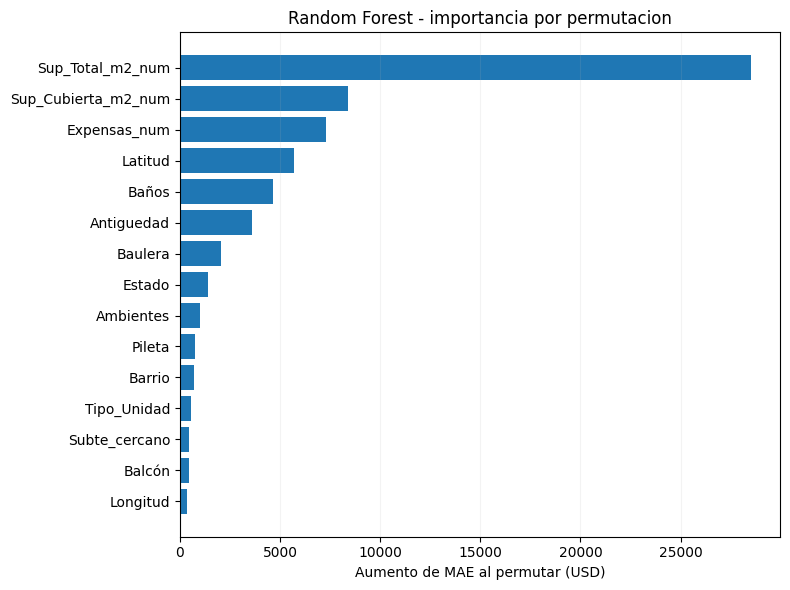

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
top_importancia = (
    importancia_rf.head(15)
    .sort_values("aumento_MAE_USD")
)
ax.barh(
    top_importancia["feature"],
    top_importancia["aumento_MAE_USD"],
)
ax.set_xlabel("Aumento de MAE al permutar (USD)")
ax.set_title("Random Forest - importancia por permutacion")
ax.grid(axis="x", alpha=0.15)
plt.tight_layout()
plt.show()

## Analisis de errores

Una metrica global puede ocultar diferencias entre segmentos. Se revisan:

- residuos del modelo;
- error por rango de precio;
- barrios con suficiente cantidad de observaciones en test.

Esto permite detectar donde el modelo es mas confiable y donde necesita interpretarse con mayor cautela.

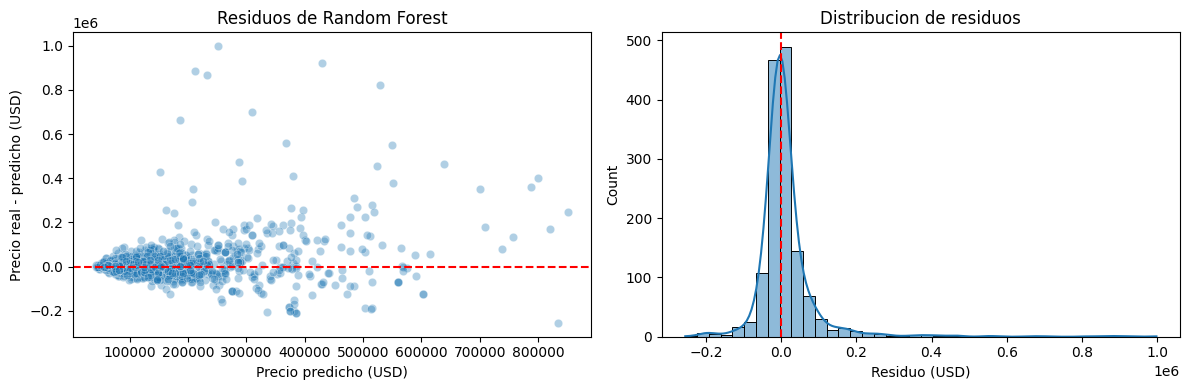

In [17]:
resultados_test = df_modelo.iloc[test_idx][[
    "Link",
    "Barrio",
    "Sup_Total_m2_num",
]].copy()

resultados_test["precio_real"] = y_test.to_numpy()
resultados_test["pred_ridge"] = ridge_pred
resultados_test["pred_rf"] = rf_pred
resultados_test["residuo_rf"] = (
    resultados_test["precio_real"]
    - resultados_test["pred_rf"]
)
resultados_test["error_abs_rf"] = resultados_test["residuo_rf"].abs()
resultados_test["error_pct_rf"] = (
    resultados_test["error_abs_rf"]
    / resultados_test["precio_real"]
    * 100
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(
    data=resultados_test,
    x="pred_rf",
    y="residuo_rf",
    alpha=0.35,
    ax=axes[0],
)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuos de Random Forest")
axes[0].set_xlabel("Precio predicho (USD)")
axes[0].set_ylabel("Precio real - predicho (USD)")

sns.histplot(
    resultados_test["residuo_rf"],
    bins=40,
    kde=True,
    ax=axes[1],
)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Distribucion de residuos")
axes[1].set_xlabel("Residuo (USD)")

plt.tight_layout()
plt.show()

In [18]:
resultados_test["rango_precio"] = pd.qcut(
    resultados_test["precio_real"],
    q=4,
    labels=["Bajo", "Medio-bajo", "Medio-alto", "Alto"],
)

error_por_rango = (
    resultados_test
    .groupby("rango_precio", observed=False)
    .agg(
        propiedades=("precio_real", "size"),
        precio_mediano=("precio_real", "median"),
        MAE_USD=("error_abs_rf", "mean"),
        MAPE_pct=("error_pct_rf", "mean"),
    )
    .round(2)
)

error_por_barrio = (
    resultados_test
    .groupby("Barrio")
    .agg(
        propiedades=("precio_real", "size"),
        precio_mediano=("precio_real", "median"),
        MAE_USD=("error_abs_rf", "mean"),
        MAPE_pct=("error_pct_rf", "mean"),
    )
    .query("propiedades >= 20")
    .sort_values("MAPE_pct")
    .round(2)
)

display(error_por_rango)
display(error_por_barrio)

,propiedades,precio_mediano,MAE_USD,MAPE_pct
rango_precio,,,,
Bajo,371,"69,500.00","15,576.03",24.80
Medio-bajo,348,"102,222.50","18,913.10",18.08
Medio-alto,356,"155,000.00","29,440.09",18.53
Alto,356,"312,500.00","101,998.86",22.89


,propiedades,precio_mediano,MAE_USD,MAPE_pct
Barrio,,,,
Parque Chacabuco,31,"145,000.00","21,437.29",13.14
San Telmo,34,"88,750.00","17,863.39",13.72
Almagro,39,"95,000.00","17,656.21",14.84
Colegiales,29,"160,000.00","27,535.60",14.97
Villa Crespo,46,"129,000.00","23,286.92",15.00
Villa Ortuzar,23,"150,000.00","68,521.98",16.33
Caballito,66,"139,550.00","30,834.49",17.24
Belgrano,41,"144,000.00","35,147.86",17.50
Barracas,28,"102,000.00","22,155.86",18.06


## Interpretacion final

### Modelo baseline

Ridge establece una referencia lineal e interpretable. Su desempeno muestra cuanto puede explicarse mediante efectos aditivos de superficie, ubicacion, estado y amenities.

### Modelo mas potente

Random Forest incorpora no linealidades e interacciones. En el test final obtiene menor MAE, MAPE y MedAE que Ridge, aunque su R2 es apenas inferior. Esa diferencia puntual de R2 es pequena y no se mantiene al cambiar las ubicaciones evaluadas.

En las cinco validaciones agrupadas repetidas, Random Forest obtiene un MAE promedio menor, un R2 promedio mayor y menor dispersion entre resultados. Esto indica que su rendimiento es mas consistente y menos dependiente de una particion particular.

Por estas razones, **Random Forest se selecciona como modelo principal**, mientras que Ridge se conserva como baseline interpretable.

### Control de fuga

El target proviene exclusivamente de precios USD observados y no se imputa. Las variables explicativas conservan sus faltantes hasta ingresar al pipeline, donde cada imputador se ajusta solo con el train correspondiente. Esto se repite tanto en el test final como en cada repeticion de validacion agrupada.

### Lectura comercial

- La metrica principal es el MAE sobre ubicaciones no vistas.
- Un residuo positivo significa que el precio publicado es mayor que la estimacion del modelo.
- Un residuo negativo significa que el aviso publica por debajo de la estimacion y puede justificar una revision.
- Esa diferencia no debe interpretarse automaticamente como oportunidad de inversion: faltan estado real, costos de obra, negociacion, impuestos, comisiones y precio efectivo de cierre.

La evaluacion agrupada es deliberadamente mas exigente que un split aleatorio. Por eso sus metricas son una aproximacion mas defendible del rendimiento sobre propiedades nuevas.